# 1. Setup y Carga de Datos

In [25]:
import os
import subprocess
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D
from statsmodels.tsa.arima.model import ARIMA

PROJECT_ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
SRC_DIR = os.path.join(PROJECT_ROOT, "src")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")

# ---------------------------------------------------------------------------
# PARÁMETROS CONFIGURABLES
# ---------------------------------------------------------------------------
MOB_MADURO = 15                 # MOB hasta el que proyectar
N_COHORTES_FUTURAS = 3          # Cantidad de cohortes sintéticas
N_COHORTES_REGRESION = 12       # Últimas N cohortes para regresión MOB 1
N_MEDIA_MOVIL = 6               # Ventana de la media móvil ponderada
ARIMA_ORDER = (1, 1, 0)         # Orden ARIMA (p, d, q)
SEASONAL_ORDER = None           # Orden estacional (P, D, Q, s) o None para ARIMA sin estacionalidad
N_ARIMA = 24                    # Últimas N cohortes para ARIMA/SARIMA
METODO_SINTETICAS = "wma"       # "regresion", "wma" o "arima"
COLOR_2024 = '#2171b5'
COLOR_2025 = '#e6550d'
COLOR_SINTETICA = '#2ca02c'
COLOR_REG = '#d62728'
COLOR_WMA = '#9467bd'
COLOR_ARIMA = '#ff7f0e'
ALPHA_INDIVIDUAL = 0.15

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Parámetros: MOB_MADURO={MOB_MADURO}, N_FUTURAS={N_COHORTES_FUTURAS}, "
      f"N_REGRESION={N_COHORTES_REGRESION}, N_WMA={N_MEDIA_MOVIL}, "
      f"ARIMA={ARIMA_ORDER}, SEASONAL={SEASONAL_ORDER}, N_ARIMA={N_ARIMA}, "
      f"METODO={METODO_SINTETICAS}")

Raíz del proyecto: d:\Python\Vintage Saldo (moroso-vencido)
Parámetros: MOB_MADURO=15, N_FUTURAS=3, N_REGRESION=12, N_WMA=6, ARIMA=(1, 1, 0), SEASONAL=None, N_ARIMA=24, METODO=wma


In [26]:
import sys
sys.path.insert(0, PROJECT_ROOT)

import src.generar_cohortes_sinteticas as gcs
import importlib
importlib.reload(gcs)

# Sobreescribir parámetros
gcs.MOB_MADURO = MOB_MADURO
gcs.N_COHORTES_FUTURAS = N_COHORTES_FUTURAS
gcs.N_COHORTES_REGRESION = N_COHORTES_REGRESION
gcs.N_MEDIA_MOVIL = N_MEDIA_MOVIL
gcs.ARIMA_ORDER = ARIMA_ORDER
gcs.SEASONAL_ORDER = SEASONAL_ORDER
gcs.N_ARIMA = N_ARIMA
gcs.METODO_SINTETICAS = METODO_SINTETICAS
gcs.main()

Generacion de Cohortes Sinteticas
Matriz leida: 49 cohortes x 49 MOBs
Parametros: MOB_MADURO=15, N_FUTURAS=3, N_REGRESION=12, N_WMA=6, ARIMA=(1, 1, 0), N_ARIMA=24, METODO=wma

Regresion MOB 1 (ultimas 12 cohortes):
  Pendiente: -0.00328 (-0.328 pp/mes)
  Intercepto: 0.20540
  Desvio residuos: 0.00938 (0.94 pp)

Media Movil Ponderada MOB 1 (ventana=6):
  Desvio residuos: 0.01297 (1.30 pp)

auto_arima MOB 1 (ultimas 24 cohortes):
  Orden seleccionado: (0, 1, 0) (por AIC)
  AIC: -127.82192208030358
  BIC: -126.68642786437442
  Test ADF: p=0.4620 -> estacionaria=NO
  Desvio residuos: 0.03232 (3.23 pp)

MOB 1 estimado para cohortes futuras:
     Cohorte |  Regresion |        WMA |      ARIMA
  ---------- | ---------- | ---------- | ----------
     2026-02 |    0.1660  |    0.1741  |    0.1743
     2026-03 |    0.1628  |    0.1750  |    0.1743
     2026-04 |    0.1595  |    0.1760  |    0.1743

Factores Chain Ladder promedio (14 transiciones):
  1->2: 1.00814
  2->3: 1.03763
  3->4: 1.07475


In [27]:
# Leer datos
matriz = pd.read_csv(os.path.join(PROCESSED_DIR, "matriz_vintage.csv"), sep=";", decimal=",", index_col=0)
sinteticas = pd.read_csv(os.path.join(PROCESSED_DIR, "cohortes_sinteticas.csv"), sep=";", decimal=",", index_col=0)
regresion = pd.read_csv(os.path.join(PROCESSED_DIR, "regresion_mob1.csv"), sep=";", decimal=",")

print(f"Cohortes históricas: {len(matriz)}")
print(f"Cohortes sintéticas: {len(sinteticas)}")
print()
print("Cohortes sintéticas generadas:")
sinteticas.style.format('{:.4f}', na_rep='-').background_gradient(cmap='YlOrRd', axis=None)

Cohortes históricas: 49
Cohortes sintéticas: 3

Cohortes sintéticas generadas:


,MOB_1,MOB_2,MOB_3,MOB_4,MOB_5,MOB_6,MOB_7,MOB_8,MOB_9,MOB_10,MOB_11,MOB_12,MOB_13,MOB_14,MOB_15
cohorte,,,,,,,,,,,,,,,
2026-02,0.1741,0.1755,0.1821,0.1957,0.2058,0.2197,0.2430,0.2486,0.2419,0.2330,0.2247,0.2171,0.2096,0.2032,0.1979
2026-03,0.1750,0.1765,0.1831,0.1968,0.2070,0.2210,0.2444,0.2500,0.2432,0.2343,0.2260,0.2183,0.2107,0.2043,0.1990
2026-04,0.1760,0.1774,0.1841,0.1979,0.2081,0.2222,0.2457,0.2514,0.2445,0.2356,0.2272,0.2195,0.2119,0.2054,0.2001


# 2. Búsqueda del Mejor Modelo (Grid Search)
Se prueban múltiples configuraciones contra las cohortes históricas.

In [31]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Grid search: probar múltiples configuraciones y rankear por MAE walk-forward
cohortes_ord = sorted(matriz.index)
mob1_all = matriz.loc[cohortes_ord, 'MOB_1']
n_total = len(cohortes_ord)

# ---------------------------------------------------------------------------
# Configuraciones a probar
# ---------------------------------------------------------------------------
arima_orders = [
    (1, 0, 0), (1, 0, 1), (0, 1, 1), (1, 1, 0),
    (1, 1, 1), (2, 1, 0), (2, 1, 1), (0, 1, 2),
    (2, 0, 1), (1, 0, 2),
]
ventanas_arima = [12, 24]

# SARIMA: estacionalidad s=12
sarima_configs = [
    # (order, seasonal_order)
    ((1, 0, 0), (1, 0, 0, 12)),
    ((1, 0, 1), (1, 0, 0, 12)),
    ((1, 1, 0), (1, 0, 0, 12)),
    ((1, 1, 1), (1, 0, 0, 12)),
    ((0, 1, 1), (1, 0, 0, 12)),
    ((1, 0, 0), (0, 1, 1, 12)),
    ((1, 0, 1), (0, 1, 1, 12)),
    ((1, 1, 1), (0, 1, 1, 12)),
    ((1, 0, 0), (1, 0, 1, 12)),
    ((1, 0, 1), (1, 0, 1, 12)),
    ((0, 1, 1), (0, 1, 1, 12)),
    ((2, 1, 1), (1, 0, 0, 12)),
]
# SARIMA necesita al menos 2*s datos = 24, usamos ventanas grandes
ventanas_sarima = [36]  # usar todas las cohortes disponibles

ventanas_wma = [4, 6, 8]
ventanas_reg = [6, 12]

resultados_grid = []

# Mínimo global para que todas las evaluaciones tengan el mismo rango
min_global = max(max(ventanas_arima), max(ventanas_wma), max(ventanas_reg))

# ---------------------------------------------------------------------------
# Funciones de backtesting
# ---------------------------------------------------------------------------
def bt_regresion(n_reg):
    errores = []
    for i in range(max(n_reg, min_global), n_total):
        x = np.arange(n_reg)
        y = mob1_all.iloc[i - n_reg:i].values
        coefs = np.polyfit(x, y, 1)
        pred = np.poly1d(coefs)(n_reg)
        errores.append(abs(pred - mob1_all.iloc[i]))
    return np.mean(errores), np.sqrt(np.mean(np.array(errores)**2)), len(errores)

def bt_wma(n_wma):
    errores = []
    for i in range(max(n_wma, min_global), n_total):
        ventana = mob1_all.iloc[i - n_wma:i].values
        pesos = np.exp(np.linspace(0, 2, n_wma))
        pesos = pesos / pesos.sum()
        wma_val = np.average(ventana, weights=pesos)
        diffs = np.diff(ventana)
        pw = np.exp(np.linspace(0, 2, len(diffs)))
        pw = pw / pw.sum()
        tendencia = np.average(diffs, weights=pw)
        pred = wma_val + tendencia
        errores.append(abs(pred - mob1_all.iloc[i]))
    return np.mean(errores), np.sqrt(np.mean(np.array(errores)**2)), len(errores)

def bt_arima(order, n_arima, seasonal_order=None):
    errores = []
    min_start_local = max(n_arima, min_global)
    for i in range(min_start_local, n_total):
        datos = mob1_all.iloc[i - n_arima:i].values
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                if seasonal_order is not None:
                    modelo = SARIMAX(datos, order=order,
                                     seasonal_order=seasonal_order,
                                     enforce_stationarity=False,
                                     enforce_invertibility=False)
                    resultado = modelo.fit(disp=False)
                else:
                    modelo = ARIMA(datos, order=order)
                    resultado = modelo.fit()
                pred = resultado.forecast(steps=1)[0]
                errores.append(abs(pred - mob1_all.iloc[i]))
        except Exception:
            pass
    if len(errores) == 0:
        return np.nan, np.nan, 0
    return np.mean(errores), np.sqrt(np.mean(np.array(errores)**2)), len(errores)

# ---------------------------------------------------------------------------
# Ejecutar
# ---------------------------------------------------------------------------
print('Evaluando configuraciones...')

# Regresión lineal
for n in ventanas_reg:
    mae, rmse, n_eval = bt_regresion(n)
    resultados_grid.append({'metodo': f'Regresión (n={n})', 'tipo': 'Regresión',
                            'mae': mae, 'rmse': rmse, 'n_eval': n_eval})

# WMA
for n in ventanas_wma:
    mae, rmse, n_eval = bt_wma(n)
    resultados_grid.append({'metodo': f'WMA (n={n})', 'tipo': 'WMA',
                            'mae': mae, 'rmse': rmse, 'n_eval': n_eval})

# ARIMA (sin estacionalidad)
n_arima_total = len(arima_orders) * len(ventanas_arima)
for idx, order in enumerate(arima_orders):
    for n in ventanas_arima:
        mae, rmse, n_eval = bt_arima(order, n)
        if not np.isnan(mae):
            resultados_grid.append({'metodo': f'ARIMA{order} (n={n})', 'tipo': 'ARIMA',
                                    'mae': mae, 'rmse': rmse, 'n_eval': n_eval})

# SARIMA (con estacionalidad s=12)
print(f'Evaluando SARIMA (s=12)... ({len(sarima_configs)} configs)')
for order, seasonal in sarima_configs:
    for n in ventanas_sarima:
        if n > n_total:
            n = n_total  # usar todo lo disponible
        mae, rmse, n_eval = bt_arima(order, n, seasonal_order=seasonal)
        if not np.isnan(mae) and n_eval > 0:
            s_label = f'({seasonal[0]},{seasonal[1]},{seasonal[2]},{seasonal[3]})'
            resultados_grid.append({
                'metodo': f'SARIMA{order}x{s_label} (n={n})',
                'tipo': 'SARIMA',
                'mae': mae, 'rmse': rmse, 'n_eval': n_eval
            })

df_grid = pd.DataFrame(resultados_grid).dropna(subset=['mae'])
df_grid = df_grid.sort_values('mae').reset_index(drop=True)
df_grid['rank'] = range(1, len(df_grid) + 1)

# ---------------------------------------------------------------------------
# Mostrar ranking
# ---------------------------------------------------------------------------
print(f'\n{"Rank":>4s} | {"Método":<40s} | {"MAE (pp)":>9s} | {"RMSE (pp)":>10s} | {"N":>4s}')
print('-' * 78)
for _, row in df_grid.iterrows():
    marker = ' ***' if row['rank'] <= 3 else ''
    print(f'{int(row["rank"]):>4d} | {row["metodo"]:<40s} | {row["mae"]*100:>8.2f}% | '
          f'{row["rmse"]*100:>9.2f}% | {int(row["n_eval"]):>4d}{marker}')

print(f'\n*** Top 3 marcados. Total: {len(df_grid)} configuraciones evaluadas')
print(f'    Cohortes disponibles: {n_total} | Evaluaciones por config: {df_grid["n_eval"].iloc[0]}')


# ─── Extracción automática de parámetros del ganador ──────────────────
import re
winner = df_grid.iloc[0]
tipo = winner['tipo']
metodo_str = winner['metodo']

# Valores por defecto de resguardo
best_wma = 6
best_reg = 12
best_arima_order = (1,1,1)
best_seasonal = None
best_n_arima = 24

if tipo == 'WMA':
    metodo = 'wma'
    m = re.search(r'n=(\d+)', metodo_str)
    if m: best_wma = int(m.group(1))
elif tipo == 'Regresión':
    metodo = 'regresion'
    m = re.search(r'n=(\d+)', metodo_str)
    if m: best_reg = int(m.group(1))
elif tipo == 'ARIMA':
    metodo = 'arima'
    m1 = re.search(r'ARIMA\((.*?)\)', metodo_str)
    m2 = re.search(r'n=(\d+)', metodo_str)
    if m1: best_arima_order = eval(f"({m1.group(1)})")
    if m2: best_n_arima = int(m2.group(1))
elif tipo == 'SARIMA':
    metodo = 'arima'
    m1 = re.search(r'SARIMA\((.*?)\)', metodo_str)
    m2 = re.search(r'x\((.*?)\)', metodo_str)
    m3 = re.search(r'n=(\d+)', metodo_str)
    if m1: best_arima_order = eval(f"({m1.group(1)})")
    if m2: best_seasonal = eval(f"({m2.group(1)})")
    if m3: best_n_arima = int(m3.group(1))
else:
    metodo = 'wma'

print("\n" + "=" * 78)
print(f"✅ Mejor configuración seleccionada automáticamente: {metodo.upper()}")
print(f"   Original: {metodo_str}")
print("=" * 78)


Evaluando configuraciones...
Evaluando SARIMA (s=12)... (12 configs)

Rank | Método                                   |  MAE (pp) |  RMSE (pp) |    N
------------------------------------------------------------------------------
   1 | SARIMA(1, 0, 0)x(1,0,0,12) (n=36)        |     1.21% |      1.46% |   13 ***
   2 | SARIMA(1, 1, 1)x(1,0,0,12) (n=36)        |     1.24% |      1.47% |   13 ***
   3 | SARIMA(0, 1, 1)x(1,0,0,12) (n=36)        |     1.24% |      1.52% |   13 ***
   4 | SARIMA(1, 0, 0)x(1,0,1,12) (n=36)        |     1.26% |      1.52% |   13
   5 | SARIMA(1, 1, 0)x(1,0,0,12) (n=36)        |     1.26% |      1.52% |   13
   6 | SARIMA(1, 0, 1)x(1,0,0,12) (n=36)        |     1.27% |      1.58% |   13
   7 | SARIMA(2, 1, 1)x(1,0,0,12) (n=36)        |     1.30% |      1.51% |   13
   8 | SARIMA(1, 0, 1)x(1,0,1,12) (n=36)        |     1.37% |      1.60% |   13
   9 | WMA (n=6)                                |     1.37% |      1.69% |   25
  10 | ARIMA(1, 1, 0) (n=24)           

In [29]:
# Backtesting walk-forward: predecir MOB 1 de cada cohorte usando solo datos anteriores
cohortes_ord = sorted(matriz.index)
mob1_all = matriz.loc[cohortes_ord, 'MOB_1']

resultados_bt = []

# Necesitamos al menos N_COHORTES_REGRESION cohortes previas para regresión,
# N_MEDIA_MOVIL para WMA, y N_ARIMA para ARIMA
min_start = max(N_COHORTES_REGRESION, N_MEDIA_MOVIL, N_ARIMA)

for i in range(min_start, len(cohortes_ord)):
    cohorte = cohortes_ord[i]
    real = mob1_all.iloc[i]

    # --- Regresión lineal (últimas N_COHORTES_REGRESION) ---
    x_reg = np.arange(N_COHORTES_REGRESION)
    y_reg = mob1_all.iloc[i - N_COHORTES_REGRESION:i].values
    coefs = np.polyfit(x_reg, y_reg, 1)
    pred_reg = np.poly1d(coefs)(N_COHORTES_REGRESION)
    residuos_reg = y_reg - np.poly1d(coefs)(x_reg)
    std_reg = np.std(residuos_reg, ddof=1)

    # --- Media móvil ponderada (últimas N_MEDIA_MOVIL) ---
    ventana = mob1_all.iloc[i - N_MEDIA_MOVIL:i].values
    pesos = np.exp(np.linspace(0, 2, N_MEDIA_MOVIL))
    pesos = pesos / pesos.sum()
    wma_val = np.average(ventana, weights=pesos)
    diffs = np.diff(ventana)
    pw = np.exp(np.linspace(0, 2, len(diffs)))
    pw = pw / pw.sum()
    tendencia = np.average(diffs, weights=pw)
    pred_wma = wma_val + tendencia
    res_wma = []
    for j in range(1, len(ventana)):
        sub = ventana[:j]
        w = np.exp(np.linspace(0, 2, len(sub)))
        w = w / w.sum()
        p = np.average(sub, weights=w)
        res_wma.append(ventana[j] - p)
    std_wma = np.std(res_wma, ddof=1) if len(res_wma) > 1 else 0.0

    # --- ARIMA (últimas N_ARIMA) ---
    datos_arima = mob1_all.iloc[i - N_ARIMA:i].values
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            modelo = ARIMA(datos_arima, order=ARIMA_ORDER)
            resultado = modelo.fit()
        pred_arima = resultado.forecast(steps=1)[0]
        std_arima = np.std(resultado.resid, ddof=1)
    except Exception:
        pred_arima = np.nan
        std_arima = np.nan

    resultados_bt.append({
        'cohorte': cohorte,
        'real': real,
        'pred_reg': pred_reg,
        'pred_wma': pred_wma,
        'pred_arima': pred_arima,
        'error_reg': pred_reg - real,
        'error_wma': pred_wma - real,
        'error_arima': pred_arima - real,
        'abs_error_reg': abs(pred_reg - real),
        'abs_error_wma': abs(pred_wma - real),
        'abs_error_arima': abs(pred_arima - real),
        'dentro_banda_reg': abs(pred_reg - real) <= std_reg,
        'dentro_banda_wma': abs(pred_wma - real) <= std_wma,
        'dentro_banda_arima': abs(pred_arima - real) <= std_arima if not np.isnan(std_arima) else False,
    })

df_bt = pd.DataFrame(resultados_bt)

# --- Métricas ---
metodos = {
    'Regresión': {'mae': 'abs_error_reg', 'err': 'error_reg', 'banda': 'dentro_banda_reg', 'color': COLOR_REG},
    'WMA': {'mae': 'abs_error_wma', 'err': 'error_wma', 'banda': 'dentro_banda_wma', 'color': COLOR_WMA},
    f'ARIMA{ARIMA_ORDER}': {'mae': 'abs_error_arima', 'err': 'error_arima', 'banda': 'dentro_banda_arima', 'color': COLOR_ARIMA},
}

print('BACKTESTING WALK-FORWARD — Predicción MOB 1 (1 paso adelante)')
print('=' * 80)
print(f'Cohortes evaluadas: {len(df_bt)} ({df_bt["cohorte"].iloc[0]} a {df_bt["cohorte"].iloc[-1]})')
print()

# Calcular métricas
metricas = {}
for nombre, cols in metodos.items():
    mae = df_bt[cols['mae']].mean()
    rmse = np.sqrt((df_bt[cols['err']] ** 2).mean())
    pct = df_bt[cols['banda']].mean() * 100
    sesgo = df_bt[cols['err']].mean()
    metricas[nombre] = {'MAE': mae, 'RMSE': rmse, 'banda': pct, 'sesgo': sesgo}

# Encontrar mejor por métrica
mejor_mae = min(metricas, key=lambda m: metricas[m]['MAE'])
mejor_rmse = min(metricas, key=lambda m: metricas[m]['RMSE'])
mejor_banda = max(metricas, key=lambda m: metricas[m]['banda'])

print(f'{"Métrica":<30s} | {"Regresión":>12s} | {"WMA":>12s} | {"ARIMA":>12s} | {"Mejor":>12s}')
print('-' * 88)
print(f'{"MAE (pp)":<30s} | {metricas["Regresión"]["MAE"]*100:>11.2f}% | '
      f'{metricas["WMA"]["MAE"]*100:>11.2f}% | '
      f'{metricas[f"ARIMA{ARIMA_ORDER}"]["MAE"]*100:>11.2f}% | {mejor_mae:>12s}')
print(f'{"RMSE (pp)":<30s} | {metricas["Regresión"]["RMSE"]*100:>11.2f}% | '
      f'{metricas["WMA"]["RMSE"]*100:>11.2f}% | '
      f'{metricas[f"ARIMA{ARIMA_ORDER}"]["RMSE"]*100:>11.2f}% | {mejor_rmse:>12s}')
print(f'{"% dentro de banda ±1σ":<30s} | {metricas["Regresión"]["banda"]:>11.1f}% | '
      f'{metricas["WMA"]["banda"]:>11.1f}% | '
      f'{metricas[f"ARIMA{ARIMA_ORDER}"]["banda"]:>11.1f}% | {mejor_banda:>12s}')
print(f'{"Sesgo medio (pp)":<30s} | {metricas["Regresión"]["sesgo"]*100:>+11.2f}% | '
      f'{metricas["WMA"]["sesgo"]*100:>+11.2f}% | '
      f'{metricas[f"ARIMA{ARIMA_ORDER}"]["sesgo"]*100:>+11.2f}% |')

print(f'\n** Mejor método por MAE: {mejor_mae} **')
print(f'** Mejor método por RMSE: {mejor_rmse} **')

BACKTESTING WALK-FORWARD — Predicción MOB 1 (1 paso adelante)
Cohortes evaluadas: 25 (2024-01 a 2026-01)

Métrica                        |    Regresión |          WMA |        ARIMA |        Mejor
----------------------------------------------------------------------------------------
MAE (pp)                       |        1.90% |        1.37% |        1.39% |          WMA
RMSE (pp)                      |        2.29% |        1.69% |        1.81% |          WMA
% dentro de banda ±1σ          |        52.0% |        72.0% |        84.0% | ARIMA(1, 1, 0)
Sesgo medio (pp)               |       +0.44% |       -0.22% |       -0.11% |

** Mejor método por MAE: WMA **
** Mejor método por RMSE: WMA **


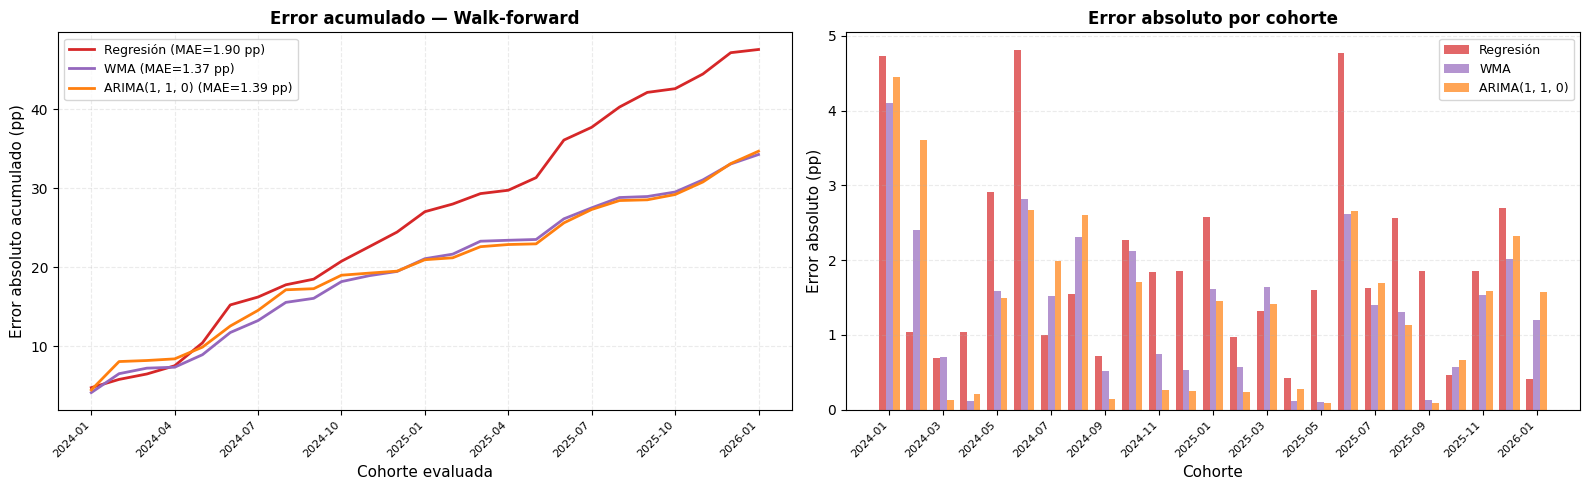


Victorias por cohorte (menor error absoluto):
  Regresión: 6/25
  WMA: 7/25
  ARIMA(1, 1, 0): 12/25


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

metodos_plot = [
    ('Regresión', 'abs_error_reg', COLOR_REG),
    ('WMA', 'abs_error_wma', COLOR_WMA),
    (f'ARIMA{ARIMA_ORDER}', 'abs_error_arima', COLOR_ARIMA),
]

# --- Panel izquierdo: errores absolutos acumulados ---
ax = axes[0]
for nombre, col, color in metodos_plot:
    mae = df_bt[col].mean()
    ax.plot(range(len(df_bt)), df_bt[col].cumsum().values * 100,
            color=color, linewidth=2, label=f'{nombre} (MAE={mae*100:.2f} pp)')
ax.set_xlabel('Cohorte evaluada', fontsize=11)
ax.set_ylabel('Error absoluto acumulado (pp)', fontsize=11)
ax.set_title('Error acumulado — Walk-forward', fontsize=12, fontweight='bold')
step = max(1, len(df_bt) // 8)
ax.set_xticks(range(0, len(df_bt), step))
ax.set_xticklabels([df_bt['cohorte'].iloc[i] for i in range(0, len(df_bt), step)],
                   rotation=45, ha='right', fontsize=8)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25, linestyle='--')

# --- Panel derecho: error por cohorte (barras agrupadas) ---
ax = axes[1]
x = np.arange(len(df_bt))
w = 0.25
for j, (nombre, col, color) in enumerate(metodos_plot):
    ax.bar(x + (j - 1) * w, df_bt[col].values * 100, w, color=color, alpha=0.7, label=nombre)
ax.set_xlabel('Cohorte', fontsize=11)
ax.set_ylabel('Error absoluto (pp)', fontsize=11)
ax.set_title('Error absoluto por cohorte', fontsize=12, fontweight='bold')
step2 = max(1, len(x) // 10)
ax.set_xticks(x[::step2])
ax.set_xticklabels([df_bt['cohorte'].iloc[i] for i in range(0, len(df_bt), step2)],
                   rotation=45, ha='right', fontsize=8)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25, linestyle='--', axis='y')

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'reports', 'backtesting_mob1.png'), dpi=150, bbox_inches='tight')
plt.show()

# Conteo de victorias
print('\nVictorias por cohorte (menor error absoluto):')
for nombre, col, _ in metodos_plot:
    otros = [c for n, c, _ in metodos_plot if n != nombre]
    gana = sum((df_bt[col] < df_bt[otros[0]]) & (df_bt[col] < df_bt[otros[1]]))
    print(f'  {nombre}: {gana}/{len(df_bt)}')

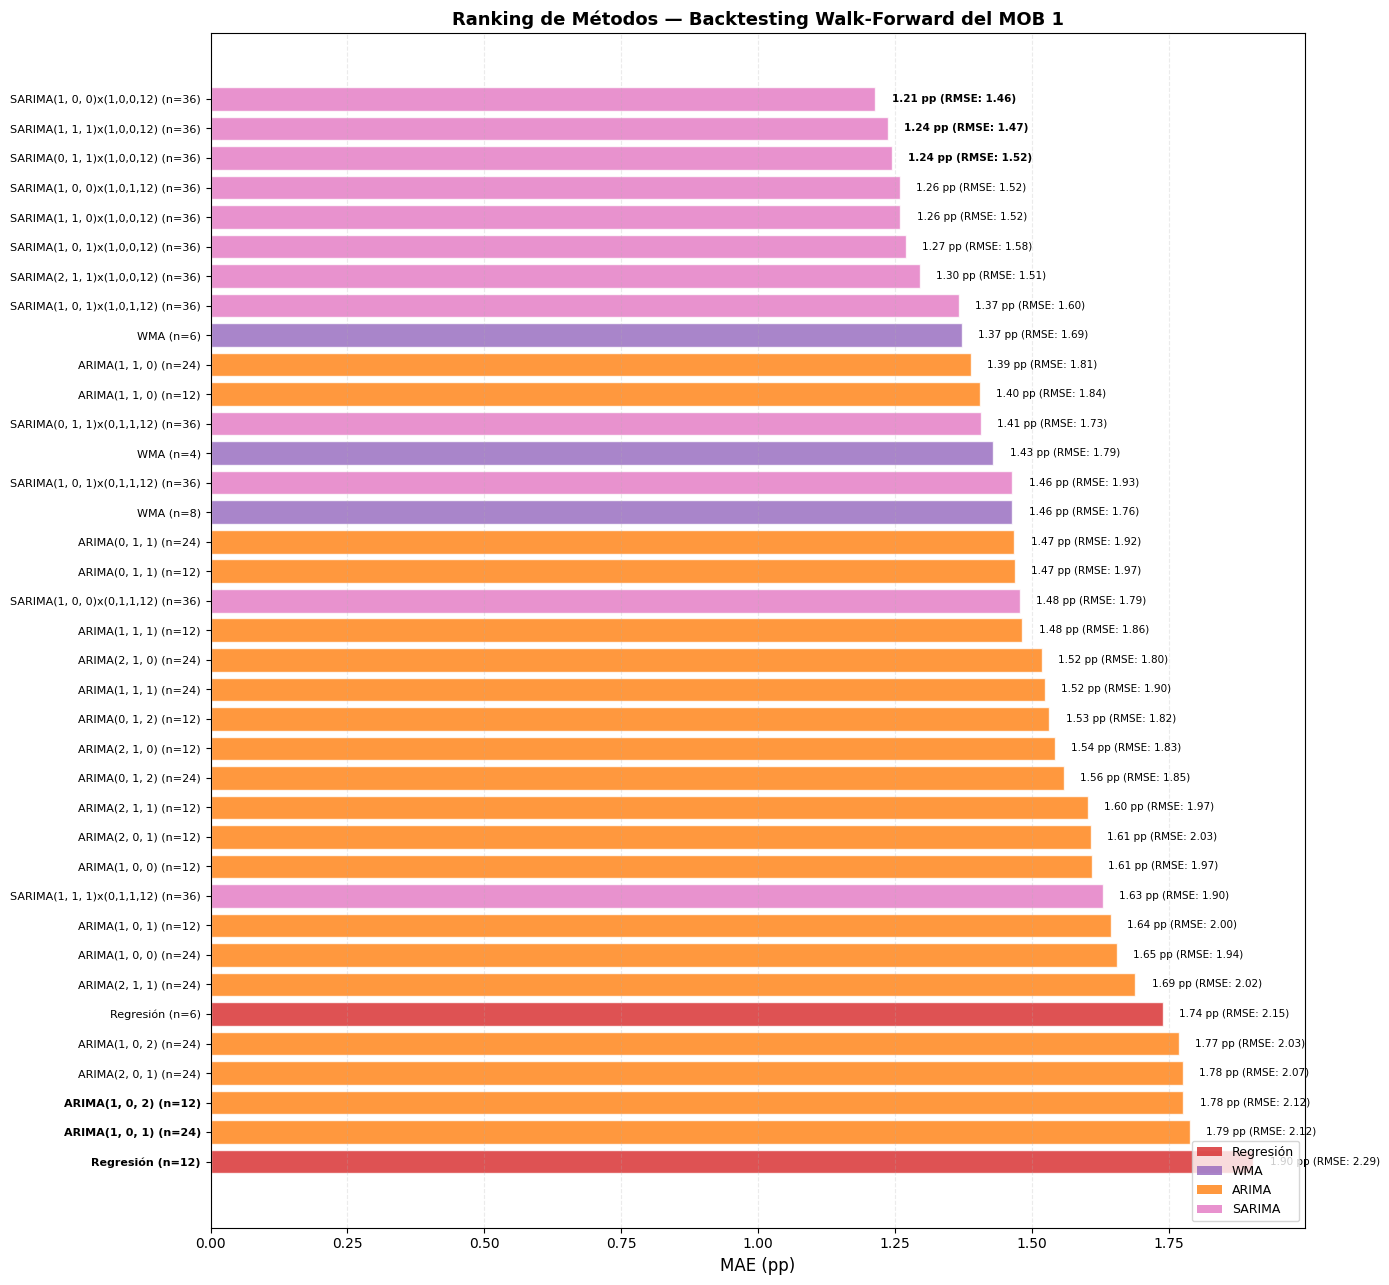


Mejor método: SARIMA(1, 0, 0)x(1,0,0,12) (n=36) con MAE=1.21 pp

Mejor de cada tipo:
  Regresión : Regresión (n=6)                          MAE=1.74 pp (rank #32)
  WMA       : WMA (n=6)                                MAE=1.37 pp (rank #9)
  ARIMA     : ARIMA(1, 1, 0) (n=24)                    MAE=1.39 pp (rank #10)
  SARIMA    : SARIMA(1, 0, 0)x(1,0,0,12) (n=36)        MAE=1.21 pp (rank #1)


In [32]:
# Gráfico de ranking
COLOR_SARIMA = '#e377c2'
fig, ax = plt.subplots(figsize=(14, max(6, len(df_grid) * 0.35)))

colores_tipo = {'Regresión': COLOR_REG, 'WMA': COLOR_WMA, 'ARIMA': COLOR_ARIMA, 'SARIMA': COLOR_SARIMA}
bars_colors = [colores_tipo[row['tipo']] for _, row in df_grid.iterrows()]

y_pos = range(len(df_grid) - 1, -1, -1)
ax.barh(y_pos, df_grid['mae'].values * 100, color=bars_colors, alpha=0.8, edgecolor='white')

# Etiquetas
for i, (_, row) in enumerate(df_grid.iterrows()):
    mae_pp = row['mae'] * 100
    rmse_pp = row['rmse'] * 100
    ax.text(mae_pp + 0.03, y_pos[i], f'{mae_pp:.2f} pp (RMSE: {rmse_pp:.2f})',
            va='center', fontsize=7.5, fontweight='bold' if i < 3 else 'normal')

ax.set_yticks(y_pos)
ax.set_yticklabels(df_grid['metodo'].values, fontsize=8)
ax.set_xlabel('MAE (pp)', fontsize=12)
ax.set_title('Ranking de Métodos — Backtesting Walk-Forward del MOB 1',
             fontsize=13, fontweight='bold')

# Leyenda
from matplotlib.patches import Patch
tipos_presentes = df_grid['tipo'].unique()
legend_elements = [Patch(facecolor=colores_tipo[t], label=t, alpha=0.8)
                   for t in ['Regresión', 'WMA', 'ARIMA', 'SARIMA'] if t in tipos_presentes]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
ax.grid(True, alpha=0.25, linestyle='--', axis='x')

# Marcar top 3 en bold
for i in range(min(3, len(df_grid))):
    idx_label = len(df_grid) - 1 - i
    ax.get_yticklabels()[idx_label].set_fontweight('bold')

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'reports', 'ranking_metodos_mob1.png'), dpi=150, bbox_inches='tight')
plt.show()

# Conclusión
mejor = df_grid.iloc[0]
print(f'\nMejor método: {mejor["metodo"]} con MAE={mejor["mae"]*100:.2f} pp')

# Mejor por tipo
print('\nMejor de cada tipo:')
for tipo in ['Regresión', 'WMA', 'ARIMA', 'SARIMA']:
    sub = df_grid[df_grid['tipo'] == tipo]
    if len(sub) > 0:
        top = sub.iloc[0]
        print(f'  {tipo:<10s}: {top["metodo"]:<40s} MAE={top["mae"]*100:.2f} pp (rank #{int(top["rank"])})')

# 3. Selección, Aplicación y Guardado de CSVs
Se usa el mejor parámetro del Grid Search para calcular las curvas futuras.

In [37]:
# ─── APLICACIÓN DEL GANADOR Y GUARDADO ───────────────────────────────────
import sys
import os
import importlib

# Asegurar que importamos del path correcto
PROJECT_ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
SRC_DIR = os.path.join(PROJECT_ROOT, "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import generar_cohortes_sinteticas as gcs
importlib.reload(gcs)

# Inyectar variables
gcs.METODO_SINTETICAS = metodo
if metodo == "wma":
    gcs.N_MEDIA_MOVIL = best_wma
elif metodo == "regresion":
    gcs.N_COHORTES_REGRESION = best_reg
elif metodo == "arima":
    gcs.ARIMA_ORDER = best_arima_order
    gcs.SEASONAL_ORDER = best_seasonal
    gcs.N_ARIMA = best_n_arima

print(f"Ejecutando script generar_cohortes_sinteticas.py con:")
print(f"  METODO_SINTETICAS = '{gcs.METODO_SINTETICAS}'")
if metodo == "wma": print(f"  N_MEDIA_MOVIL = {gcs.N_MEDIA_MOVIL}")
if metodo == "regresion": print(f"  N_COHORTES_REGRESION = {gcs.N_COHORTES_REGRESION}")
if metodo == "arima":
    print(f"  ARIMA_ORDER = {gcs.ARIMA_ORDER}")
    print(f"  SEASONAL_ORDER = {gcs.SEASONAL_ORDER}")

# Ejecutar calcular y guardar
gcs.main()

print("\n✅ Los CSVs han sido actualizados con los mejores parámetros del Grid Search.")
print("   → data/processed/cohortes_sinteticas.csv")
print("   → data/processed/regresion_mob1.csv")
print("   -----------------------------------------------------------------------")
print("   Listos para ser integrados orgánicamente en el tablero_resumen_ejecutivo")

# ─── Recargar en memoria para la visualización ───────────────────────────
sinteticas = pd.read_csv(OUTPUT_SINTETICAS, sep=';', decimal=',', index_col=0)
regresion = pd.read_csv(OUTPUT_REGRESION, sep=';', decimal=',')
print('Memoria actualizada con los CSVs finales para graficar.')


Ejecutando script generar_cohortes_sinteticas.py con:
  METODO_SINTETICAS = 'arima'
  ARIMA_ORDER = (1, 0, 0)
  SEASONAL_ORDER = (1, 0, 0, 12)
Generacion de Cohortes Sinteticas
Matriz leida: 49 cohortes x 49 MOBs
Parametros: MOB_MADURO=15, N_FUTURAS=3, N_REGRESION=12, N_WMA=6, ARIMA=(1, 0, 0), N_ARIMA=36, METODO=arima

Regresion MOB 1 (ultimas 12 cohortes):
  Pendiente: -0.00328 (-0.328 pp/mes)
  Intercepto: 0.20540
  Desvio residuos: 0.00938 (0.94 pp)

Media Movil Ponderada MOB 1 (ventana=6):
  Desvio residuos: 0.01297 (1.30 pp)

auto_arima MOB 1 (ultimas 36 cohortes):
  Orden seleccionado: (0, 1, 0) (por AIC)
  AIC: -181.54348166392057
  BIC: -179.98813360243116
  Test ADF: p=0.3303 -> estacionaria=NO
  Desvio residuos: 0.02330 (2.33 pp)

MOB 1 estimado para cohortes futuras:
     Cohorte |  Regresion |        WMA |      ARIMA
  ---------- | ---------- | ---------- | ----------
     2026-02 |    0.1660  |    0.1741  |    0.1743
     2026-03 |    0.1628  |    0.1750  |    0.1743
     

# 4. Visualización de Resultados

---
## 2. Estimación del MOB 1: Tres Métodos

Tres métodos para estimar la mora inicial de cohortes futuras:
- **Regresión lineal** (rojo): baseline, usa las últimas N cohortes
- **Media móvil ponderada** (violeta): pesos exponenciales, captura mejor cambios recientes
- **ARIMA** (naranja): modelo autorregresivo con media móvil, captura autocorrelación

Todos con bandas de confianza de **±1 desvío estándar**.

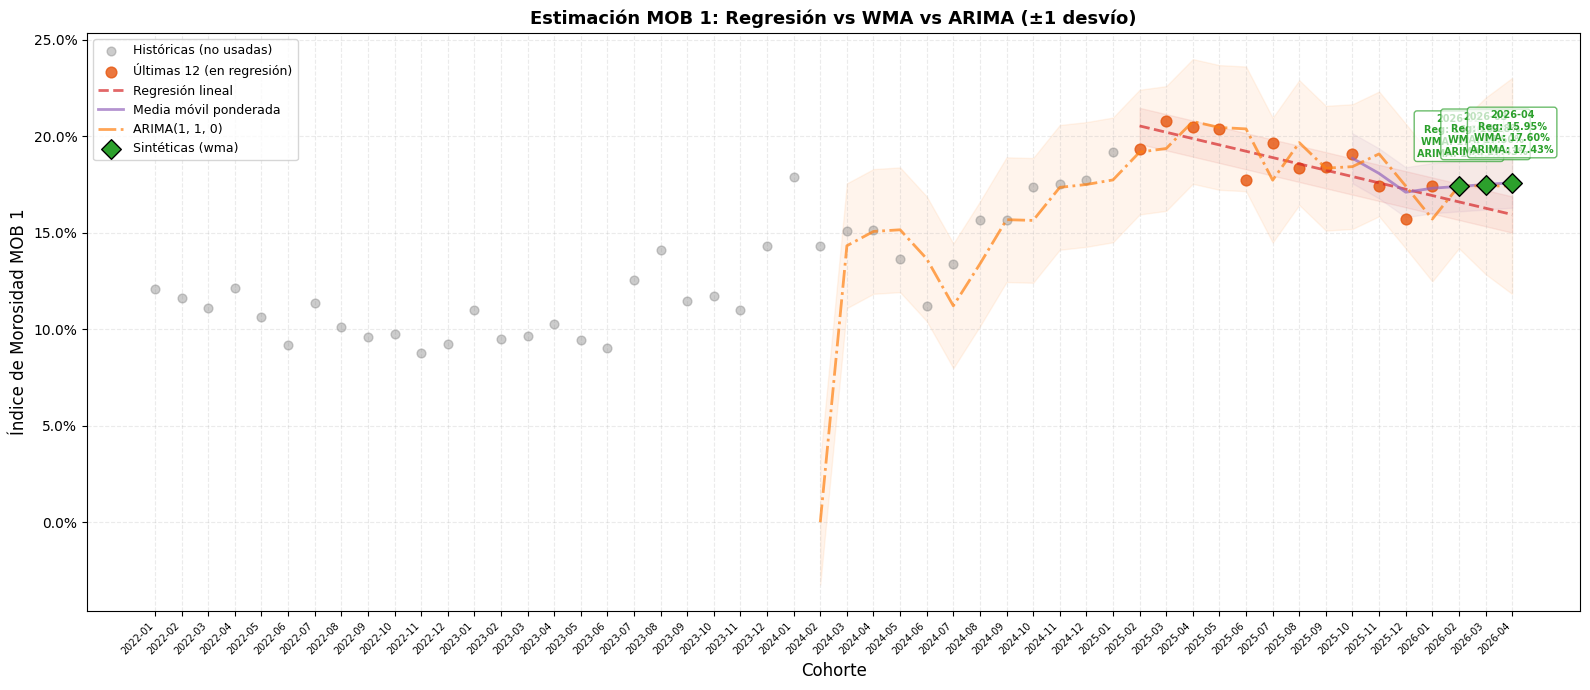

In [28]:
fig, ax = plt.subplots(figsize=(16, 7))

hist = regresion[regresion['tipo'] == 'historica'].copy()
sint = regresion[regresion['tipo'] == 'sintetica'].copy()
en_reg = hist[hist['en_regresion'] == True]
fuera_reg = hist[hist['en_regresion'] == False]

# Puntos históricos fuera de regresión
ax.scatter(range(len(fuera_reg)), fuera_reg['mob1_observado'].values,
           color='gray', s=40, alpha=0.4, zorder=2, label='Históricas (no usadas)')

# Puntos históricos en regresión
offset = len(fuera_reg)
ax.scatter(range(offset, offset + len(en_reg)), en_reg['mob1_observado'].values,
           color=COLOR_2025, s=60, alpha=0.8, zorder=3, label=f'Últimas {N_COHORTES_REGRESION} (en regresión)')

sint_x = list(range(len(hist), len(hist) + len(sint)))

# --- Helper para graficar método ---
def plot_metodo(col_val, col_sup, col_inf, color, label, linestyle='--'):
    mask_h = hist[col_val].notna()
    h = hist[mask_h]
    if len(h) == 0:
        return
    x_h = [list(hist['cohorte']).index(c) for c in h['cohorte']]
    y_h = h[col_val].values
    y_s = sint[col_val].values

    all_x = x_h + sint_x
    all_y = np.concatenate([y_h, y_s])
    ax.plot(all_x, all_y, linestyle, color=color, linewidth=2, alpha=0.7, zorder=4, label=label)

    if col_sup in sint.columns:
        sup_h = h[col_sup].values
        inf_h = h[col_inf].values
        sup_s = sint[col_sup].values
        inf_s = sint[col_inf].values
        ax.fill_between(all_x,
                        np.concatenate([inf_h, inf_s]),
                        np.concatenate([sup_h, sup_s]),
                        alpha=0.08, color=color)

# Regresión lineal
plot_metodo('mob1_regresion', 'mob1_reg_sup', 'mob1_reg_inf', COLOR_REG, 'Regresión lineal', '--')

# Media móvil ponderada
plot_metodo('mob1_wma', 'mob1_wma_sup', 'mob1_wma_inf', COLOR_WMA, 'Media móvil ponderada', '-')

# ARIMA
if 'mob1_arima' in regresion.columns:
    plot_metodo('mob1_arima', 'mob1_arima_sup', 'mob1_arima_inf', COLOR_ARIMA, f'ARIMA{ARIMA_ORDER}', '-.')

# Puntos sintéticos (método seleccionado)
col_map = {'wma': 'mob1_wma', 'arima': 'mob1_arima', 'regresion': 'mob1_regresion'}
col_sint = col_map.get(METODO_SINTETICAS, 'mob1_regresion')
sint_y_sel = sint[col_sint].values
ax.scatter(sint_x, sint_y_sel, color=COLOR_SINTETICA, s=100, marker='D',
           edgecolors='black', linewidth=1, zorder=5, label=f'Sintéticas ({METODO_SINTETICAS})')

# Etiquetas sintéticas (tres métodos)
for i, (_, row) in enumerate(sint.iterrows()):
    lbl = f"{row['cohorte']}\nReg: {row['mob1_regresion']:.2%}\nWMA: {row['mob1_wma']:.2%}"
    if 'mob1_arima' in row.index and pd.notna(row['mob1_arima']):
        lbl += f"\nARIMA: {row['mob1_arima']:.2%}"
    ax.annotate(lbl,
                xy=(sint_x[i], sint_y_sel[i]),
                xytext=(0, 20), textcoords='offset points',
                fontsize=7, fontweight='bold', color=COLOR_SINTETICA,
                ha='center', va='bottom', zorder=6,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor=COLOR_SINTETICA))

# Eje X
all_cohortes = list(hist['cohorte']) + list(sint['cohorte'])
ax.set_xticks(range(len(all_cohortes)))
ax.set_xticklabels(all_cohortes, rotation=45, ha='right', fontsize=7)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
ax.set_xlabel('Cohorte', fontsize=12)
ax.set_ylabel('Índice de Morosidad MOB 1', fontsize=12)
ax.set_title('Estimación MOB 1: Regresión vs WMA vs ARIMA (±1 desvío)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.25, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'reports', 'regresion_mob1.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Curvas sintéticas vs históricas

Las curvas **verdes punteadas** son las cohortes sintéticas.
Se superponen sobre las curvas históricas para evaluar si la proyección
es coherente con el comportamiento observado.

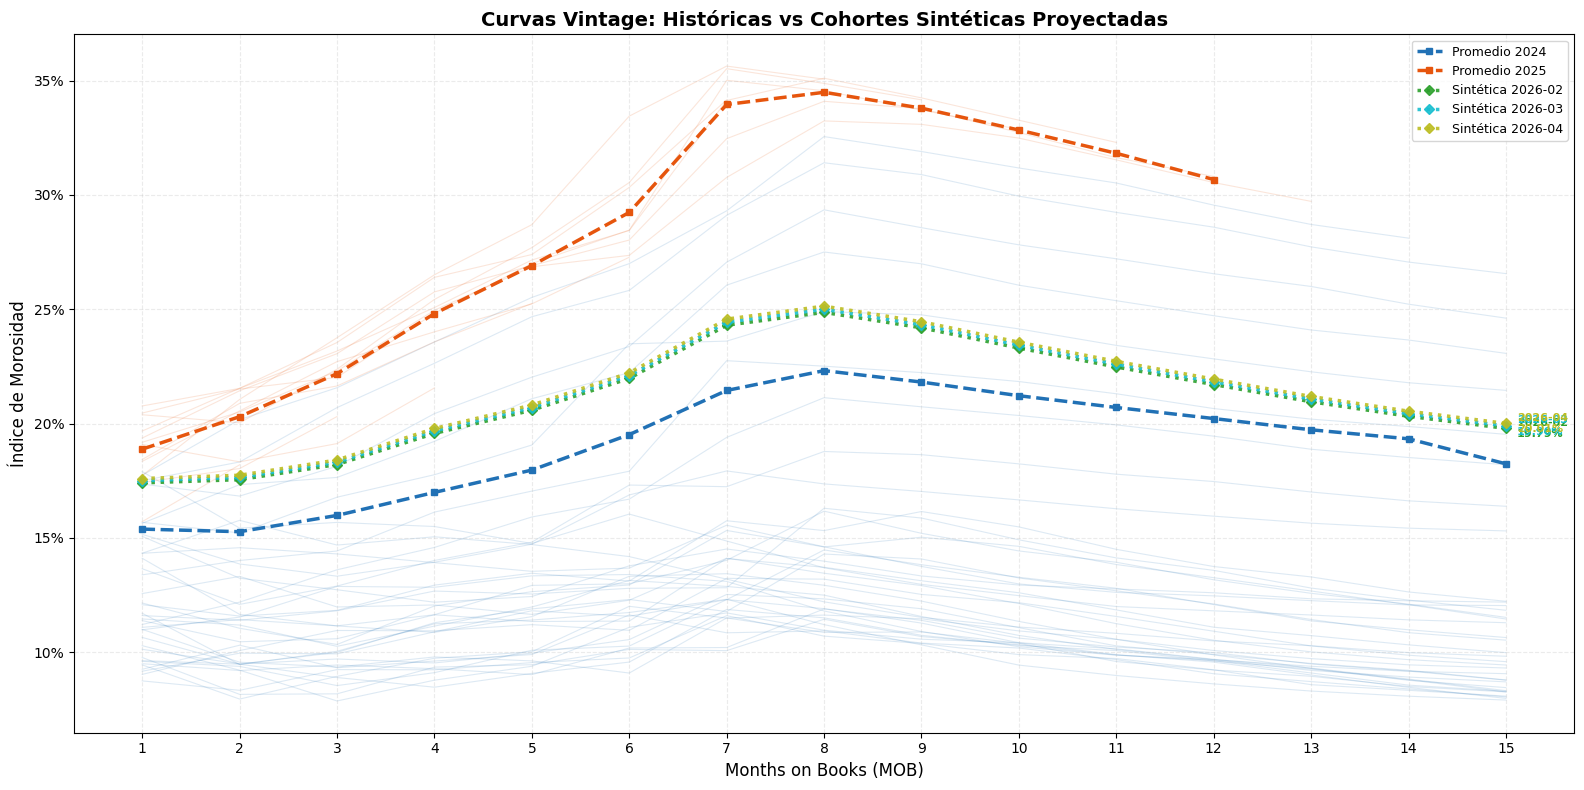

In [33]:
fig, ax = plt.subplots(figsize=(16, 8))

cohortes_ord = sorted(matriz.index)

# Históricas individuales (semitransparentes)
for cohorte in cohortes_ord:
    vals = matriz.loc[cohorte].dropna()
    mobs = [int(c.replace('MOB_', '')) for c in vals.index]
    # Solo hasta MOB maduro para comparar
    mobs_f = [m for m in mobs if m <= MOB_MADURO]
    vals_f = [vals[f'MOB_{m}'] for m in mobs_f]
    color = COLOR_2024 if cohorte < '2025' else COLOR_2025
    ax.plot(mobs_f, vals_f, color=color, alpha=ALPHA_INDIVIDUAL, linewidth=0.8, zorder=1)

# Promedios históricos
for year, color, cohs in [('2024', COLOR_2024, [c for c in cohortes_ord if c.startswith('2024')]),
                           ('2025', COLOR_2025, [c for c in cohortes_ord if c.startswith('2025')])]:
    if len(cohs) < 2:
        continue
    mobs_p, vals_p = [], []
    for m in range(1, MOB_MADURO + 1):
        col = f'MOB_{m}'
        if col not in matriz.columns:
            break
        v = matriz.loc[cohs, col].dropna()
        if len(v) >= 2:
            mobs_p.append(m)
            vals_p.append(v.mean())
    if mobs_p:
        ax.plot(mobs_p, vals_p, color=color, linewidth=2.5, linestyle='--',
                marker='s', markersize=4, zorder=4, label=f'Promedio {year}')

# Sintéticas
colores_sint = ['#2ca02c', '#17becf', '#bcbd22']
for i, cohorte in enumerate(sinteticas.index):
    vals = sinteticas.loc[cohorte].dropna()
    mobs = [int(c.replace('MOB_', '')) for c in vals.index]
    color = colores_sint[i % len(colores_sint)]
    ax.plot(mobs, vals.values, color=color, linewidth=2.5, linestyle=':',
            marker='D', markersize=5, zorder=5, alpha=0.9, label=f'Sintética {cohorte}')
    # Etiqueta al final
    ax.annotate(f'{cohorte}\n{vals.iloc[-1]:.2%}',
                xy=(mobs[-1], vals.iloc[-1]),
                xytext=(8, 0), textcoords='offset points',
                fontsize=8, fontweight='bold', color=color, va='center', zorder=6)

ax.set_xlabel('Months on Books (MOB)', fontsize=12)
ax.set_ylabel('Índice de Morosidad', fontsize=12)
ax.set_title('Curvas Vintage: Históricas vs Cohortes Sintéticas Proyectadas',
             fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_xticks(range(1, MOB_MADURO + 1))
ax.grid(True, alpha=0.25, linestyle='--')
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'reports', 'cohortes_sinteticas.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Detalle MOB a MOB de las cohortes sintéticas

Tabla y gráfico con la evolución proyectada mes a mes de cada cohorte sintética.
Los factores CL aplicados son los mismos para todas (promedio histórico ponderado).

In [34]:
# Tabla detallada
print('DETALLE MOB A MOB - COHORTES SINTÉTICAS')
print('=' * 80)
for cohorte in sinteticas.index:
    vals = sinteticas.loc[cohorte].dropna()
    print(f'\nCohorte {cohorte}:')
    print(f'{"MOB":>6s} | {"Índice":>10s} | {"Factor CL":>10s} | {"Δ vs MOB ant":>12s} | {"Factor conv":>11s}')
    print('-' * 60)
    mob1 = vals.iloc[0]
    for j, (col, val) in enumerate(vals.items()):
        mob = int(col.replace('MOB_', ''))
        if j == 0:
            print(f'{mob:>6d} | {val:>10.4f} | {"(inicio)":>10s} | {"--":>12s} | {1.000:>11.3f}')
        else:
            prev = vals.iloc[j-1]
            factor_cl = val / prev
            delta = val - prev
            fc = val / mob1
            print(f'{mob:>6d} | {val:>10.4f} | {factor_cl:>10.5f} | {delta:>+12.4f} | {fc:>11.3f}')
print('\n' + '=' * 80)

DETALLE MOB A MOB - COHORTES SINTÉTICAS

Cohorte 2026-02:
   MOB |     Índice |  Factor CL | Δ vs MOB ant | Factor conv
------------------------------------------------------------
     1 |     0.1741 |   (inicio) |           -- |       1.000
     2 |     0.1755 |    1.00814 |      +0.0014 |       1.008
     3 |     0.1821 |    1.03763 |      +0.0066 |       1.046
     4 |     0.1957 |    1.07475 |      +0.0136 |       1.124
     5 |     0.2058 |    1.05182 |      +0.0101 |       1.183
     6 |     0.2197 |    1.06754 |      +0.0139 |       1.262
     7 |     0.2430 |    1.10589 |      +0.0233 |       1.396
     8 |     0.2486 |    1.02311 |      +0.0056 |       1.428
     9 |     0.2419 |    0.97285 |      -0.0067 |       1.390
    10 |     0.2330 |    0.96341 |      -0.0089 |       1.339
    11 |     0.2247 |    0.96444 |      -0.0083 |       1.291
    12 |     0.2171 |    0.96583 |      -0.0077 |       1.247
    13 |     0.2096 |    0.96540 |      -0.0075 |       1.204
    14 |     

---
## 5. Comparación: Mora última proyectada

Compara el índice al MOB maduro entre cohortes históricas (observado) y sintéticas.

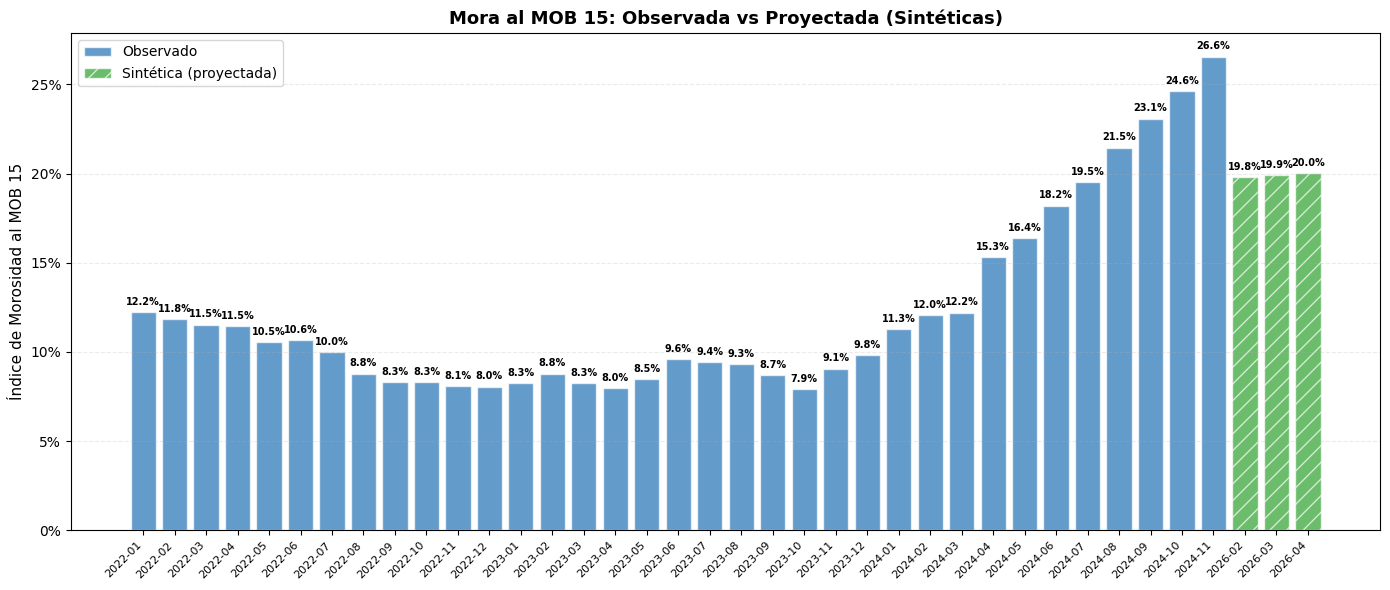

In [35]:
mob_col = f'MOB_{MOB_MADURO}'

# Históricas con dato al MOB maduro
hist_maduro = matriz[mob_col].dropna()

# Sintéticas al MOB maduro
sint_maduro = sinteticas[mob_col] if mob_col in sinteticas.columns else pd.Series(dtype=float)

fig, ax = plt.subplots(figsize=(14, 6))

# Barras históricas
colores_h = [COLOR_2024 if c < '2025' else COLOR_2025 for c in hist_maduro.index]
x_h = range(len(hist_maduro))
ax.bar(x_h, hist_maduro.values, color=colores_h, alpha=0.7, edgecolor='white', label='Observado')

# Barras sintéticas
x_s = range(len(hist_maduro), len(hist_maduro) + len(sint_maduro))
ax.bar(x_s, sint_maduro.values, color=COLOR_SINTETICA, alpha=0.7, edgecolor='white',
       hatch='//', label='Sintética (proyectada)')

# Etiquetas
all_labels = list(hist_maduro.index) + list(sint_maduro.index)
all_vals = list(hist_maduro.values) + list(sint_maduro.values)
for i, (lbl, val) in enumerate(zip(all_labels, all_vals)):
    ax.text(i, val + 0.003, f'{val:.1%}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(range(len(all_labels)))
ax.set_xticklabels(all_labels, rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_ylabel(f'Índice de Morosidad al MOB {MOB_MADURO}', fontsize=11)
ax.set_title(f'Mora al MOB {MOB_MADURO}: Observada vs Proyectada (Sintéticas)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.25, linestyle='--', axis='y')

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'reports', 'mora_ultima_sinteticas.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Resumen ejecutivo

In [36]:
print('=' * 70)
print('RESUMEN - COHORTES SINTÉTICAS PROYECTADAS')
print('=' * 70)

# Regresión
en_reg = regresion[regresion['en_regresion'] == True]
residuos = en_reg['mob1_observado'].values - en_reg['mob1_regresion'].values
std_res = residuos.std()
r2 = 1 - (residuos**2).sum() / ((en_reg['mob1_observado'] - en_reg['mob1_observado'].mean())**2).sum()

print(f'\n1) Regresión Lineal del MOB 1:')
print(f'   Cohortes usadas: {len(en_reg)} | R²: {r2:.3f} | Desvío: {std_res*100:.2f} pp')

# WMA
sint_data = regresion[regresion['tipo'] == 'sintetica']
if 'mob1_wma_sup' in regresion.columns:
    std_wma_val = sint_data['mob1_wma_sup'].iloc[0] - sint_data['mob1_wma'].iloc[0]
    print(f'\n2) Media Móvil Ponderada (ventana={N_MEDIA_MOVIL}):')
    print(f'   Pesos exponenciales | Desvío: {std_wma_val*100:.2f} pp')

# ARIMA
if 'mob1_arima_sup' in regresion.columns:
    std_arima_val = sint_data['mob1_arima_sup'].iloc[0] - sint_data['mob1_arima'].iloc[0]
    print(f'\n3) ARIMA{ARIMA_ORDER} (últimas {N_ARIMA} cohortes):')
    print(f'   Modelo autorregresivo | Desvío: {std_arima_val*100:.2f} pp')

# Tabla comparativa de sintéticas
mob_col = f'MOB_{MOB_MADURO}'
print(f'\nCohortes sintéticas (método: {METODO_SINTETICAS}):')
header = f'  {"Cohorte":>10s} | {"MOB1 Reg":>9s} | {"MOB1 WMA":>9s} | {"MOB1 ARIMA":>10s} | {"MOB"+str(MOB_MADURO):>8s} | {"FC":>6s}'
print(header)
print(f'  {"-"*10} | {"-"*9} | {"-"*9} | {"-"*10} | {"-"*8} | {"-"*6}')

col_map = {'wma': 'mob1_wma', 'arima': 'mob1_arima', 'regresion': 'mob1_regresion'}
col_sel = col_map.get(METODO_SINTETICAS, 'mob1_regresion')

for _, row in sint_data.iterrows():
    cohorte = row['cohorte']
    mob1_sel = row[col_sel]
    mob15 = sinteticas.loc[cohorte, mob_col] if cohorte in sinteticas.index and mob_col in sinteticas.columns else None
    arima_str = f'{row["mob1_arima"]:.2%}' if 'mob1_arima' in row.index and pd.notna(row['mob1_arima']) else '-'
    if mob15 is not None:
        fc = mob15 / mob1_sel
        print(f'  {cohorte:>10s} | {row["mob1_regresion"]:>8.2%} | {row["mob1_wma"]:>8.2%} | {arima_str:>10s} | {mob15:>7.2%} | {fc:>6.3f}')

# Backtesting
if 'df_bt' in dir():
    print(f'\nBacktesting walk-forward ({len(df_bt)} cohortes):')
    for nombre in ['Regresión', 'WMA', f'ARIMA{ARIMA_ORDER}']:
        m = metricas[nombre]
        print(f'  {nombre:<20s}: MAE={m["MAE"]*100:.2f}pp, RMSE={m["RMSE"]*100:.2f}pp, banda±1σ={m["banda"]:.0f}%')
    print(f'  ** Mejor por MAE: {mejor_mae} **')

# Comparar con históricas
hist_maduro = matriz[mob_col].dropna()
sint_maduro = sinteticas[mob_col] if mob_col in sinteticas.columns else pd.Series(dtype=float)
if len(hist_maduro) > 0 and len(sint_maduro) > 0:
    prom_hist = hist_maduro.mean()
    prom_sint = sint_maduro.mean()
    diff = prom_sint - prom_hist
    print(f'\nComparación al MOB {MOB_MADURO}:')
    print(f'  Promedio históricas: {prom_hist:.2%}')
    print(f'  Promedio sintéticas: {prom_sint:.2%}')
    print(f'  Diferencia: {diff:+.2%} ({"sintéticas más altas" if diff > 0 else "sintéticas más bajas"})')

print('\n' + '=' * 70)

RESUMEN - COHORTES SINTÉTICAS PROYECTADAS

1) Regresión Lineal del MOB 1:
   Cohortes usadas: 12 | R²: 0.614 | Desvío: 0.90 pp

2) Media Móvil Ponderada (ventana=6):
   Pesos exponenciales | Desvío: 1.30 pp

3) ARIMA(1, 1, 0) (últimas 24 cohortes):
   Modelo autorregresivo | Desvío: 3.23 pp

Cohortes sintéticas (método: wma):
     Cohorte |  MOB1 Reg |  MOB1 WMA | MOB1 ARIMA |    MOB15 |     FC
  ---------- | --------- | --------- | ---------- | -------- | ------
     2026-02 |   16.60% |   17.41% |     17.43% |  19.79% |  1.137
     2026-03 |   16.28% |   17.50% |     17.43% |  19.90% |  1.137
     2026-04 |   15.95% |   17.60% |     17.43% |  20.01% |  1.137

Backtesting walk-forward (25 cohortes):
  Regresión           : MAE=1.90pp, RMSE=2.29pp, banda±1σ=52%
  WMA                 : MAE=1.37pp, RMSE=1.69pp, banda±1σ=72%
  ARIMA(1, 1, 0)      : MAE=1.39pp, RMSE=1.81pp, banda±1σ=84%
  ** Mejor por MAE: WMA **

Comparación al MOB 15:
  Promedio históricas: 12.17%
  Promedio sintéticas: 